<a href="https://colab.research.google.com/github/Tengoku1/DataScienceProject/blob/main/Data_Science_Exploration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [19]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV

In [2]:
df_death_mortality = pd.read_csv("/content/drug_Mortality2019-2021.csv")
df_drug_seized = pd.read_csv("/content/drug_seizures2019-2021.csv")
df_isSuseptible = pd.read_csv("/content/df_drug_suseptability2019-2021 (2).csv")
gdf_us = gpd.read_file("/content/cb_2018_us_county_20m (1).zip")
df_drug_seized = df_drug_seized.drop(columns="Unnamed: 0")
df_death_mortality = df_death_mortality.drop(columns="Unnamed: 0")
df_isSuseptible = df_isSuseptible.drop(columns="Unnamed: 0")

In [3]:
gdf_us["FIPS"] = (
    gdf_us["STATEFP"].str.lstrip("0") +
    gdf_us["COUNTYFP"]
).astype(int)

In [4]:
gdf_us.loc[gdf_us["FIPS"] == 46102, 'FIPS'] = 46113

In [5]:
gdf_counties_overdose = gdf_us.merge(
    df_death_mortality,
    on="FIPS",
    how="outer"  # outer join will help us detect counties that failed to join
    )

In [6]:
gdf_counties_cleaned = gdf_counties_overdose.dropna(subset="STATEFP")

(np.float64(-126.0), np.float64(-66.0), np.float64(24.0), np.float64(50.0))

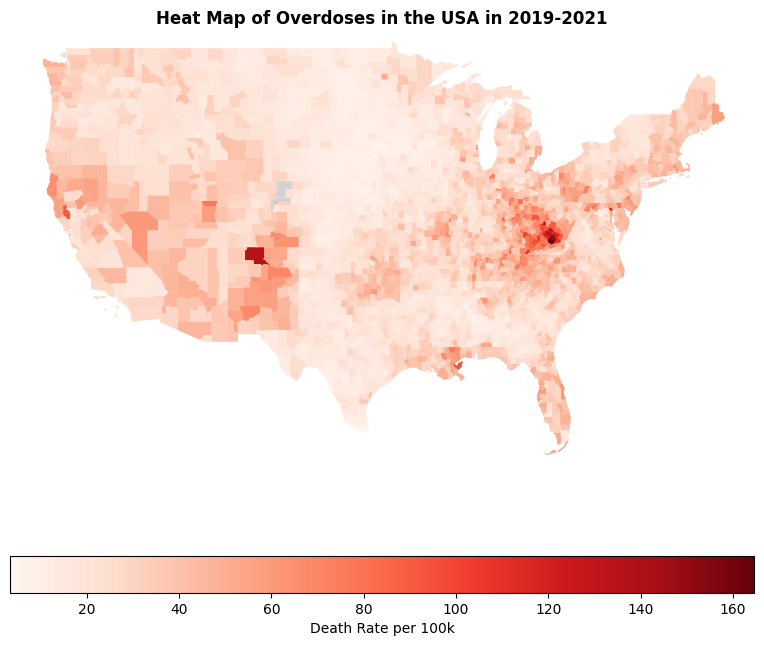

In [7]:
ax = gdf_counties_cleaned.plot(
    column="Model-based Death Rate",
    legend=True,
    legend_kwds={
        'label': "Death Rate per 100k",
        'orientation': "horizontal",
        'shrink': 0.6},
    missing_kwds={
        "color": "lightgrey",      # The color for the unknown counties
    },
    cmap="Reds",
    figsize=(16, 8))
ax.set_title("Heat Map of Overdoses in the USA in 2019-2021", fontweight='bold')
# Focus on the continental U.S.
ax.set_xlim(-126, -66)
ax.set_ylim(24, 50)
ax.axis('off')

In [8]:
sns.set_theme(style="whitegrid")

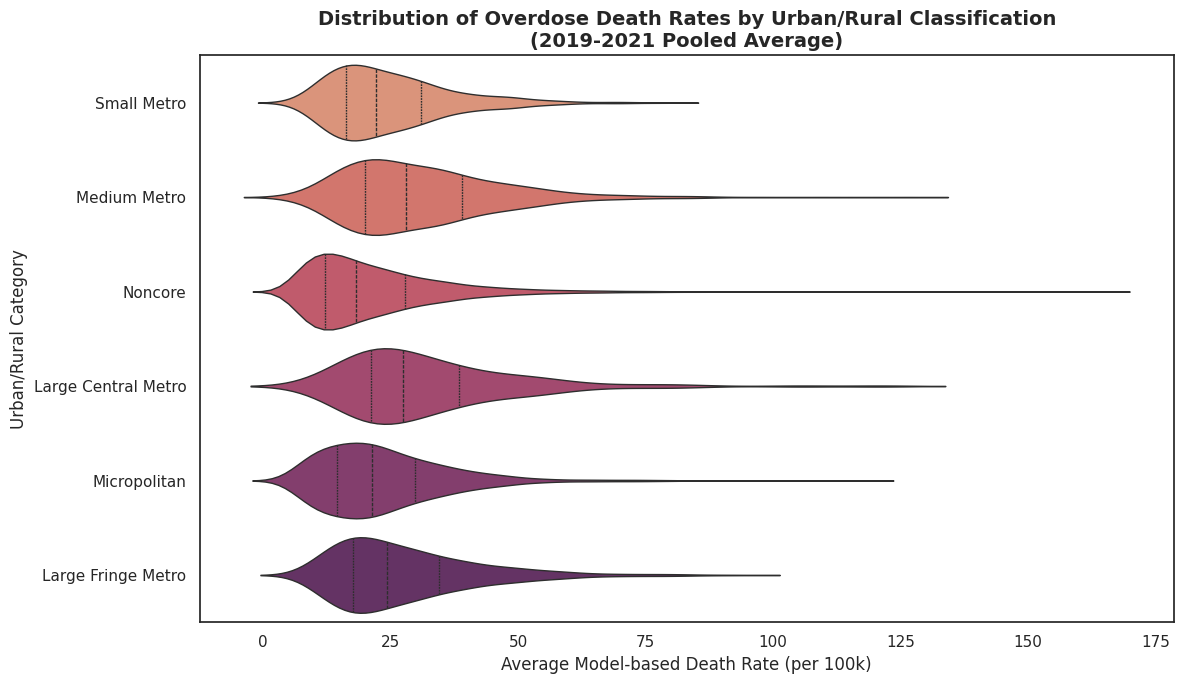

In [17]:
plot_data = df_isSuseptible.dropna(subset=['Model-based Death Rate', 'Urban/Rural Category'])
# Set the figure size to match your original aspect ratio
plt.figure(figsize=(12, 7))

# Create the violin plot
sns.violinplot(
    data=df_isSuseptible,
    x='Model-based Death Rate',
    y='Urban/Rural Category',
    hue='Urban/Rural Category',
    palette='flare', # 'flare' or 'magma' closely matches your current color scheme
    inner='quartile',
    linewidth=1
)

# Add titles and labels
plt.title('Distribution of Overdose Death Rates by Urban/Rural Classification\n(2019-2021 Pooled Average)',
          fontsize=14, fontweight='bold')
plt.xlabel('Average Model-based Death Rate (per 100k)', fontsize=12)
plt.ylabel('Urban/Rural Category', fontsize=12)

# Improve layout and display
plt.tight_layout()
plt.show()

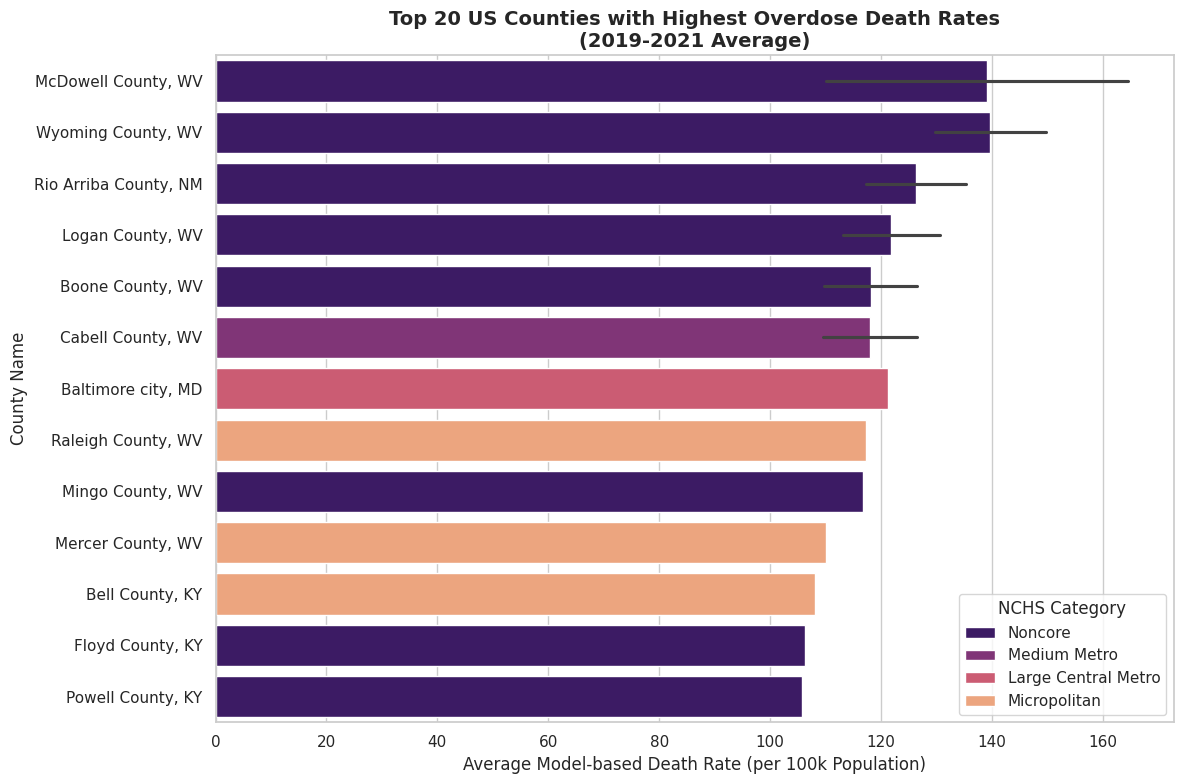

In [10]:
# 1. Load and Clean the data
# We use the susceptibility dataset which has the death rates and urban categories
df = pd.read_csv('/content/df_drug_suseptability2019-2021 (2).csv')
plot_data = df.dropna(subset=['Model-based Death Rate', 'Urban/Rural Category'])

# 2. Filter for the "Top 20" highest death rates
# We sort the data descending and take the first 20 rows
top_20 = plot_data.sort_values('Model-based Death Rate', ascending=False).head(20)

# 3. Set up the visual theme
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 8))

# 4. Create the Horizontal Bar Plot
# We use 'hue' to color-code by the Urban/Rural Category
sns.barplot(
    data=top_20,
    x='Model-based Death Rate',
    y='County',
    hue='Urban/Rural Category',
    dodge=False,      # Keeps bars aligned to the y-axis labels
    palette='magma'   # Using a high-contrast palette
)

# 5. Final Styling
plt.title('Top 20 US Counties with Highest Overdose Death Rates\n(2019-2021 Average)',
          fontsize=14, fontweight='bold')
plt.xlabel('Average Model-based Death Rate (per 100k Population)', fontsize=12)
plt.ylabel('County Name', fontsize=12)
plt.legend(title='NCHS Category', loc='lower right')

plt.tight_layout()
plt.show()

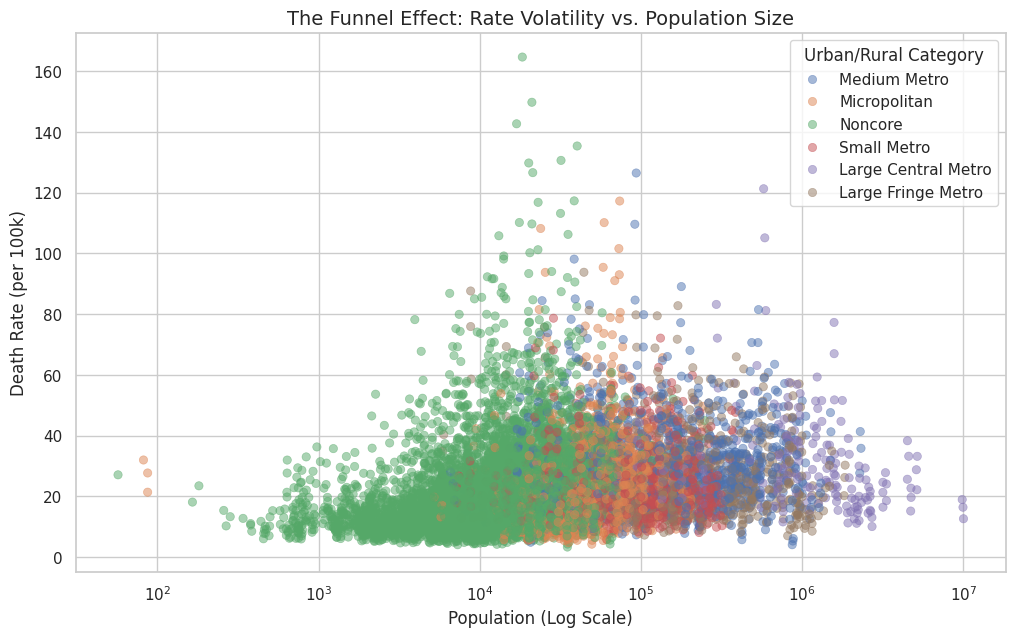

In [11]:
# 2. Data Cleaning: Population is a string with commas (e.g., "55,769")
# We must convert it to a float to plot it on a numeric axis
df_death_mortality['Population_Num'] = df_death_mortality['Population'].str.replace(',', '').astype(float)

# Set the visual theme
sns.set_theme(style="whitegrid")

# ---------------------------------------------------------
# GRAPH 1: THE FUNNEL PLOT (Population vs. Death Rate)
# ---------------------------------------------------------
plt.figure(figsize=(12, 7))

# We use a log scale because populations range from 500 to 10,000,000
sns.scatterplot(
    data=df_death_mortality,
    x='Population_Num',
    y='Model-based Death Rate',
    hue='Urban/Rural Category',
    alpha=0.5,
    edgecolor=None
)

plt.xscale('log') # This makes it easier to see small counties
plt.title('The Funnel Effect: Rate Volatility vs. Population Size', fontsize=14)
plt.xlabel('Population (Log Scale)', fontsize=12)
plt.ylabel('Death Rate (per 100k)', fontsize=12)
plt.show()

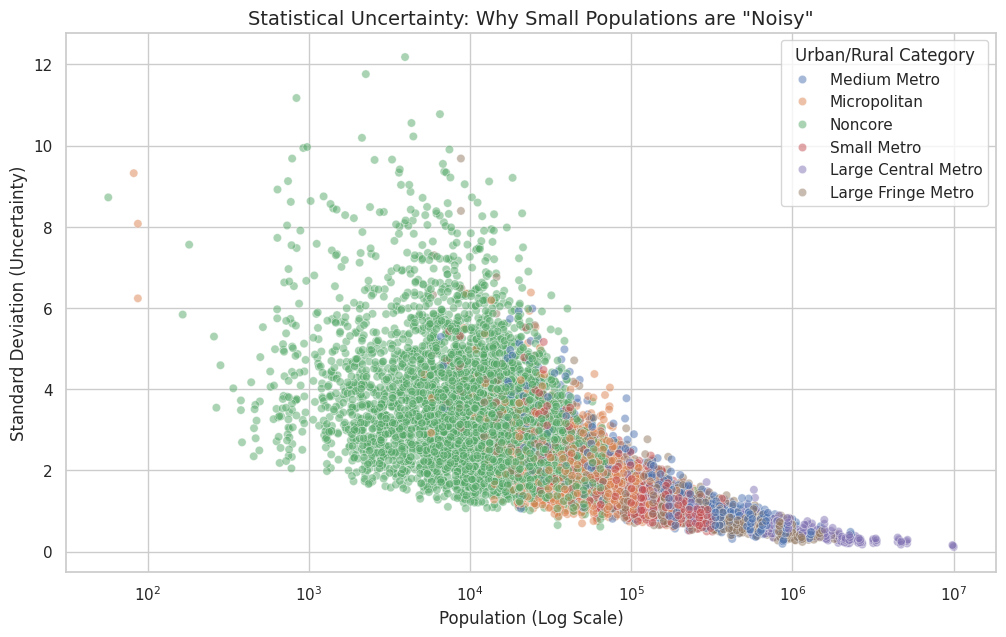

In [12]:
# ---------------------------------------------------------
# GRAPH 2: UNCERTAINTY (Population vs. Standard Deviation)
# ---------------------------------------------------------
plt.figure(figsize=(12, 7))

sns.scatterplot(
    data=df_death_mortality,
    x='Population_Num',
    y='Standard Deviation',
    hue='Urban/Rural Category',
    alpha=0.5
)

plt.xscale('log')
plt.title('Statistical Uncertainty: Why Small Populations are "Noisy"', fontsize=14)
plt.xlabel('Population (Log Scale)', fontsize=12)
plt.ylabel('Standard Deviation (Uncertainty)', fontsize=12)
plt.show()

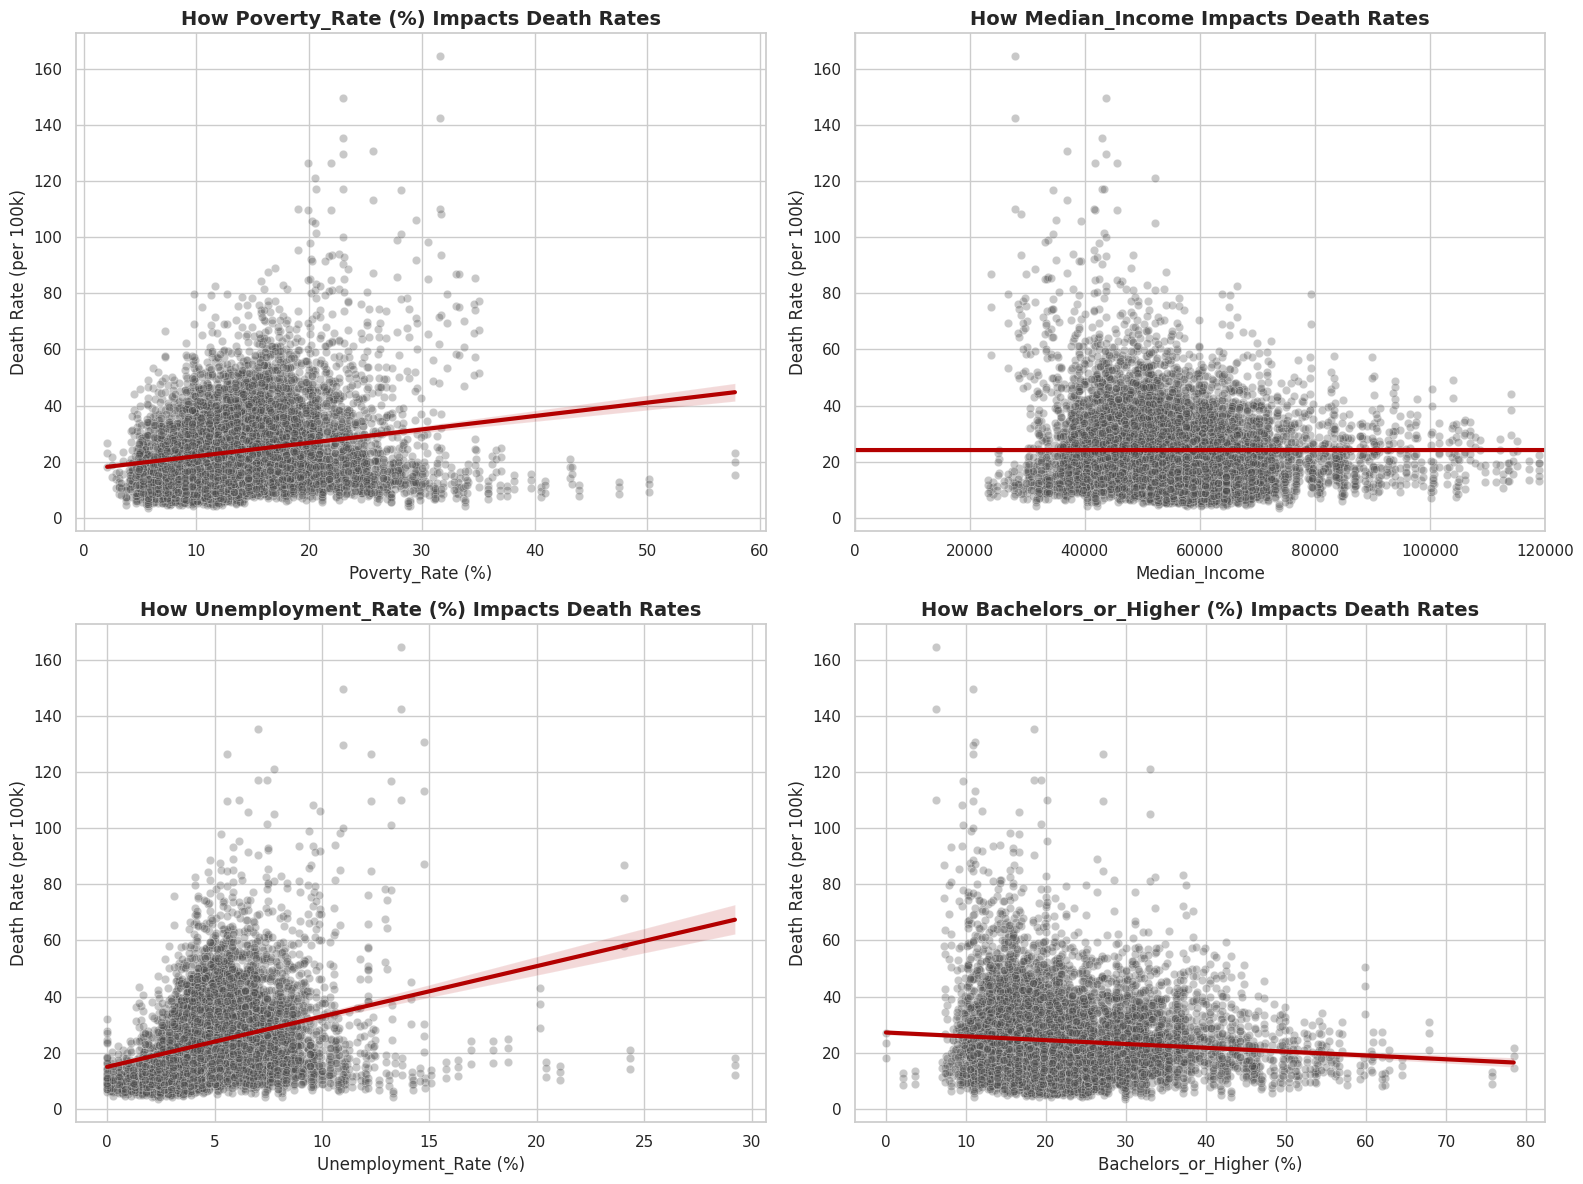

In [13]:
# 1. Define your socioeconomic features
features = ['Poverty_Rate (%)', 'Median_Income', 'Unemployment_Rate (%)', 'Bachelors_or_Higher (%)']
target = 'Model-based Death Rate'

# 2. Set up a 2x2 grid of plots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten() # Flattens the 2x2 matrix into a simple list of 4 axes so we can loop through them

# 3. Loop through each feature and build its plot
for i, feature in enumerate(features):
    # The actual scatter points
    sns.scatterplot(
        data=df_isSuseptible,
        x=feature,
        y=target,
        alpha=0.3,       # Makes the dots slightly transparent to handle overlapping
        color='#4a4a4a', # Professional grey
        ax=axes[i]
    )

    # Add a bold trendline to instantly show the relationship
    sns.regplot(
        data=df_isSuseptible,
        x=feature,
        y=target,
        scatter=False,   # We already plotted the scatter above
        color='#b30000', # Deep red for the trendline
        line_kws={'linewidth': 3},
        ax=axes[i]
    )

    # Clean up the titles and labels
    axes[i].set_title(f'How {feature} Impacts Death Rates', fontsize=14, fontweight='bold')
    axes[i].set_ylabel('Death Rate (per 100k)')
    axes[i].set_xlabel(feature)

    # --- THE FIX ---
    # Zoom in on Median Income to cut off the extreme outliers
    if feature == 'Median_Income': # Corrected feature name
        axes[i].set_xlim(0, 120000) # Caps the graph at $120k. Adjust this number if needed!

# 4. Adjust layout and display
plt.tight_layout()
plt.show()

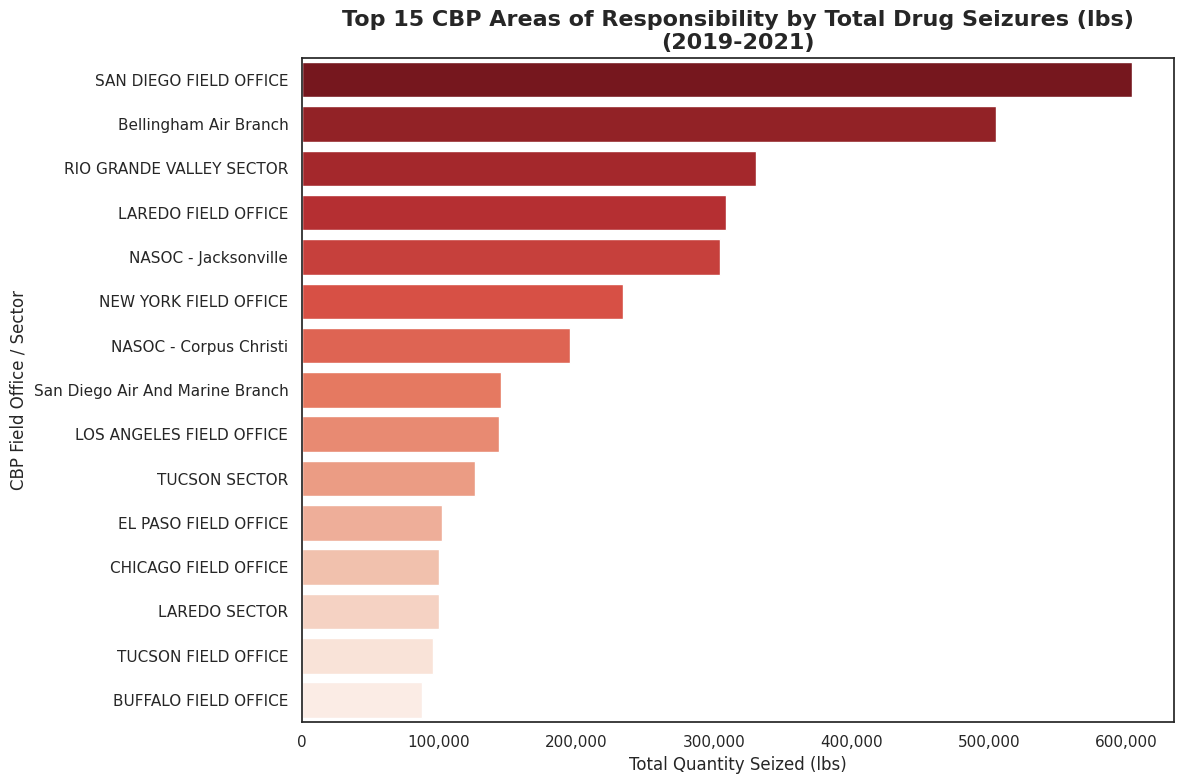

In [18]:
# 2. Aggregate the data
# We group by the 'Area of Responsibility' (Field Office/Sector)
# and sum the 'Sum Qty (lbs)' column to get the total weight per location.
top_locations = (
    df_drug_seized.groupby('Area of Responsibility')['Sum Qty (lbs)']
    .sum()
    .sort_values(ascending=False) # Sort so the largest bars are at the top
    .head(15)                      # Take only the top 15 for a clean graph
    .reset_index()
)

# 3. Create the Visualization
plt.figure(figsize=(12, 8))
sns.barplot(
    data=top_locations,
    x='Sum Qty (lbs)',
    y='Area of Responsibility',
    hue='Area of Responsibility',
    palette='Reds_r' # 'Reds_r' uses a reversed red palette (darkest at the top)
)

# 4. Final Formatting
plt.title('Top 15 CBP Areas of Responsibility by Total Drug Seizures (lbs)\n(2019-2021)',
          fontsize=16, fontweight='bold')
plt.xlabel('Total Quantity Seized (lbs)', fontsize=12)
plt.ylabel('CBP Field Office / Sector', fontsize=12)

# This helper adds commas to the numbers on the X-axis (e.g., 100,000 instead of 100000)
plt.gca().xaxis.set_major_formatter(plt.matplotlib.ticker.StrMethodFormatter('{x:,.0f}'))

plt.tight_layout()
plt.show()

Best Parameters: {'classifier__metric': 'euclidean', 'classifier__n_neighbors': 5, 'classifier__weights': 'distance'}
Best CV Score: 78.97%
Final Test Accuracy: 79.92%


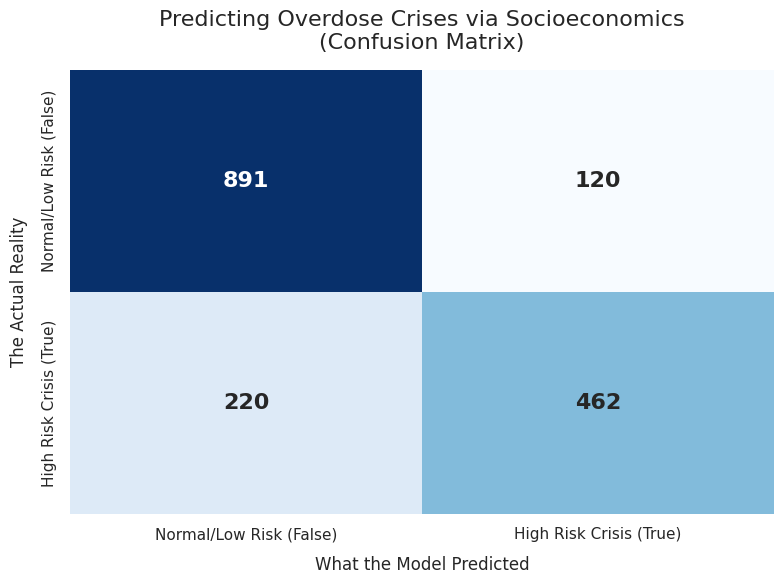

Success! Your presentation graph has been saved as 'KNN_Confusion_Matrix_Results.png'.


In [21]:
# 1. Define which columns need which preprocessing
numeric_features = ['Poverty_Rate (%)', 'Unemployment_Rate (%)', 'Bachelors_or_Higher (%)']
categorical_features = ['Urban/Rural Category']

# 2. Build the ColumnTransformer
# This applies the correct transformation to the correct columns simultaneously
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_features)
    ])
# --- Start of fix: Define X, y and split data ---
# Define target variable 'isSuseptible' as binary based on 'Model-based Death Rate'
# Using the median death rate as a threshold for 'high risk crisis'
# Combine all features
all_features = numeric_features + categorical_features
target_variable = 'isSuseptible'

# Drop rows with NaN values in the selected features or target before splitting
df_clean = df_isSuseptible.dropna(subset=all_features + [target_variable]).copy()

# Define X and y
X = df_clean[all_features]
y = df_clean[target_variable]

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# --- End of fix ---

# 4. Modify the Pipeline
# We leave n_neighbors blank or at default because GridSearchCV will fill it
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', KNeighborsClassifier())
])

# 5. Define the Hyperparameter Grid
# Note the naming convention: [step_name]__[parameter_name]
param_grid = {
    'classifier__n_neighbors': [3, 5, 7, 9, 11, 15, 21],
    'classifier__weights': ['uniform', 'distance'],
    'classifier__metric': ['euclidean', 'manhattan']
}

# 6. Set up GridSearchCV
# cv=5 means 5-fold cross-validation
grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='accuracy', n_jobs=-1)

# 7. Fit the Grid Search
# This replaces pipeline.fit(). It will run (7 k-values * 2 weights * 2 metrics) * 5 folds = 140 total fits
grid_search.fit(X_train, y_train)

# 8. Get the best results
best_model = grid_search.best_estimator_
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best CV Score: {grid_search.best_score_ * 100:.2f}%")

# 9. Evaluate on the final Test Set (the data the model hasn't seen yet)
predictions = best_model.predict(X_test)
accuracy = accuracy_score(y_test, predictions)
cm = confusion_matrix(y_test, predictions) # Fixed: changed y_pred to predictions

print(f"Final Test Accuracy: {accuracy * 100:.2f}%")

# Create a beautiful heatmap for your slides
plt.figure(figsize=(8, 6))
sns.set_theme(style="white")

# Map the boolean values to readable labels for the audience
labels = ['Normal/Low Risk (False)', 'High Risk Crisis (True)']

# Draw the heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=labels, yticklabels=labels,
            annot_kws={"size": 16, "weight": "bold"})

plt.title('Predicting Overdose Crises via Socioeconomics\n(Confusion Matrix)', fontsize=16, pad=15)
plt.xlabel('What the Model Predicted', fontsize=12, labelpad=10)
plt.ylabel('The Actual Reality', fontsize=12, labelpad=10)

# Save the image to your folder so you can drag it into PowerPoint/Google Slides
plt.tight_layout()
plt.show()

print("Success! Your presentation graph has been saved as 'KNN_Confusion_Matrix_Results.png'.")